In [49]:
import fastf1
import pandas as pd
import matplotlib.pyplot as plt

In [50]:
session = fastf1.get_session(2025, "Monaco", "R")
session.load()

Request for URL https://raw.githubusercontent.com/theOehrly/f1schedule/master/schedule_2025.json failed; using cached response
Traceback (most recent call last):
  File "d:\Documents\Data Analysis Projects\FastF1\.venv\Lib\site-packages\urllib3\connectionpool.py", line 788, in urlopen
    response = self._make_request(
        conn,
    ...<10 lines>...
        **response_kw,
    )
  File "d:\Documents\Data Analysis Projects\FastF1\.venv\Lib\site-packages\urllib3\connectionpool.py", line 534, in _make_request
    response = conn.getresponse()
  File "d:\Documents\Data Analysis Projects\FastF1\.venv\Lib\site-packages\urllib3\connection.py", line 571, in getresponse
    httplib_response = super().getresponse()
  File "C:\Users\HP-VICTUS\AppData\Local\Python\pythoncore-3.14-64\Lib\http\client.py", line 1459, in getresponse
    response.begin()
    ~~~~~~~~~~~~~~^^
  File "C:\Users\HP-VICTUS\AppData\Local\Python\pythoncore-3.14-64\Lib\http\client.py", line 336, in begin
    version, status

In [51]:
laps = session.laps

In [52]:
laps.shape

(1425, 31)

In [53]:
laps.columns

Index(['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint',
       'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time',
       'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime',
       'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest',
       'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime',
       'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason',
       'FastF1Generated', 'IsAccurate'],
      dtype='object')

In [54]:
laps["TrackStatus"].value_counts()

TrackStatus
1      1249
12       51
2        38
6        28
671      20
21       19
16       12
126       8
Name: count, dtype: int64

In [55]:
laps["Deleted"].value_counts()

Deleted
False    1411
True       14
Name: count, dtype: int64

In [56]:
laps["IsAccurate"].value_counts()

IsAccurate
True     1271
False     154
Name: count, dtype: int64

In [57]:
laps["Driver"].value_counts()

Driver
VER    78
PIA    78
NOR    78
LEC    78
HAM    78
LAW    77
OCO    77
HAD    77
HUL    76
STR    76
TSU    76
ALB    76
SAI    76
BOR    76
RUS    76
COL    76
BEA    76
ANT    75
ALO    37
GAS     8
Name: count, dtype: int64

In [58]:
laps["Driver"].value_counts().sort_index()

Driver
ALB    76
ALO    37
ANT    75
BEA    76
BOR    76
COL    76
GAS     8
HAD    77
HAM    78
HUL    76
LAW    77
LEC    78
NOR    78
OCO    77
PIA    78
RUS    76
SAI    76
STR    76
TSU    76
VER    78
Name: count, dtype: int64

In [59]:
norris_laps = laps[laps["Driver"] == "NOR"]

In [60]:
norris_laps[
    ["LapNumber", "LapTime", "Compound", "TyreLife", "TrackStatus"]
].head(15)

,LapNumber,LapTime,Compound,TyreLife,TrackStatus
734,1.0,0 days 00:01:23.340000,MEDIUM,1.0,12
735,2.0,0 days 00:01:44.634000,MEDIUM,2.0,16
736,3.0,0 days 00:01:49.015000,MEDIUM,3.0,6
737,4.0,0 days 00:01:41.564000,MEDIUM,4.0,671
738,5.0,0 days 00:01:18.050000,MEDIUM,5.0,1
739,6.0,0 days 00:01:19.172000,MEDIUM,6.0,1
740,7.0,0 days 00:01:18.470000,MEDIUM,7.0,1
741,8.0,0 days 00:01:17.626000,MEDIUM,8.0,12
742,9.0,0 days 00:01:22.148000,MEDIUM,9.0,2
743,10.0,0 days 00:01:20.385000,MEDIUM,10.0,2


In [61]:
laps["TrackStatus"].value_counts().sort_index()

TrackStatus
1      1249
12       51
126       8
16       12
2        38
21       19
6        28
671      20
Name: count, dtype: int64

In [62]:
laps[
    ["LapNumber", "TrackStatus"]
].drop_duplicates().head(100)

,LapNumber,TrackStatus
0,1.0,12
1,2.0,16
2,3.0,6
3,4.0,671
4,5.0,1
...,...,...
77,78.0,1
78,1.0,126
79,2.0,6
122,37.0,12


In [63]:
norris_laps[["LapNumber", "LapTime"]].head(10)

,LapNumber,LapTime
734,1.0,0 days 00:01:23.340000
735,2.0,0 days 00:01:44.634000
736,3.0,0 days 00:01:49.015000
737,4.0,0 days 00:01:41.564000
738,5.0,0 days 00:01:18.050000
739,6.0,0 days 00:01:19.172000
740,7.0,0 days 00:01:18.470000
741,8.0,0 days 00:01:17.626000
742,9.0,0 days 00:01:22.148000
743,10.0,0 days 00:01:20.385000


In [64]:
norris_laps["LapTime"].dtype

dtype('<m8[ns]')

In [65]:
norris_laps = norris_laps.copy()

norris_laps["LapTimeSeconds"] = (
    norris_laps["LapTime"].dt.total_seconds()
)

In [66]:
norris_laps[
    ["LapNumber", "LapTime", "LapTimeSeconds"]
].head(10)

,LapNumber,LapTime,LapTimeSeconds
734,1.0,0 days 00:01:23.340000,83.340
735,2.0,0 days 00:01:44.634000,104.634
736,3.0,0 days 00:01:49.015000,109.015
737,4.0,0 days 00:01:41.564000,101.564
738,5.0,0 days 00:01:18.050000,78.050
739,6.0,0 days 00:01:19.172000,79.172
740,7.0,0 days 00:01:18.470000,78.470
741,8.0,0 days 00:01:17.626000,77.626
742,9.0,0 days 00:01:22.148000,82.148
743,10.0,0 days 00:01:20.385000,80.385


In [67]:
norris_laps["LapTimeSeconds"].mean()

np.float64(77.35696153846155)

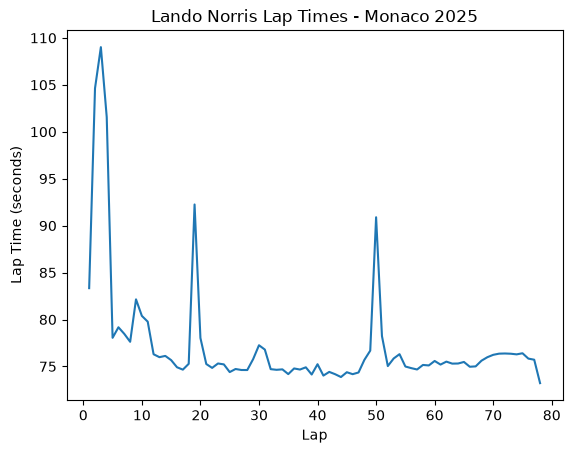

In [68]:
plt.plot(
    norris_laps["LapNumber"],
    norris_laps["LapTimeSeconds"]
)

plt.xlabel("Lap")
plt.ylabel("Lap Time (seconds)")
plt.title("Lando Norris Lap Times - Monaco 2025")

plt.show()

In [69]:
norris_laps[
    norris_laps["LapTimeSeconds"] > 90
][
    [
        "LapNumber",
        "LapTimeSeconds",
        "PitInTime",
        "PitOutTime",
        "Compound",
        "TyreLife",
        "TrackStatus"
    ]
]

,LapNumber,LapTimeSeconds,PitInTime,PitOutTime,Compound,TyreLife,TrackStatus
735,2.0,104.634,NaT,NaT,MEDIUM,2.0,16
736,3.0,109.015,NaT,NaT,MEDIUM,3.0,6
737,4.0,101.564,NaT,NaT,MEDIUM,4.0,671
752,19.0,92.254,0 days 01:22:00.706000,NaT,MEDIUM,19.0,1
783,50.0,90.893,0 days 02:01:03.269000,NaT,HARD,31.0,1


In [74]:
laps[
    laps["LapNumber"].isin([1, 2, 3, 4, 5])
][
    ["Driver", "LapNumber", "LapTime", "TrackStatus"]
].sort_values(["LapNumber", "Driver"])

,Driver,LapNumber,LapTime,TrackStatus
428,ALB,1.0,0 days 00:01:31.479000,12
161,ALO,1.0,0 days 00:01:28.332000,12
86,ANT,1.0,0 days 00:01:34.721000,126
1349,BEA,1.0,0 days 00:02:19.932000,126
966,BOR,1.0,0 days 00:02:25.564000,126
...,...,...,...,...
1199,RUS,5.0,0 days 00:01:20.576000,1
1046,SAI,5.0,0 days 00:01:20.580000,1
280,STR,5.0,0 days 00:01:20.285000,1
356,TSU,5.0,0 days 00:01:18.663000,1


In [75]:
norris_laps[
    ["LapNumber", "Compound", "TyreLife", "PitInTime", "PitOutTime"]
].dropna(subset=["PitInTime", "PitOutTime"], how="all")

,LapNumber,Compound,TyreLife,PitInTime,PitOutTime
752,19.0,MEDIUM,19.0,0 days 01:22:00.706000,NaT
753,20.0,HARD,1.0,NaT,0 days 01:22:25.221000
783,50.0,HARD,31.0,0 days 02:01:03.269000,NaT
784,51.0,HARD,1.0,NaT,0 days 02:01:26.738000


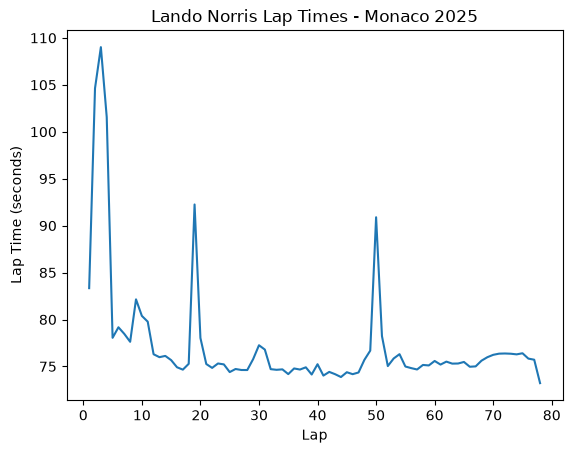

In [76]:
plt.plot(
    norris_laps["LapNumber"],
    norris_laps["LapTimeSeconds"]
)

plt.xlabel("Lap")
plt.ylabel("Lap Time (seconds)")
plt.title("Lando Norris Lap Times - Monaco 2025")

plt.show()

In [77]:
norris_laps.groupby(
    ["Compound", "Stint"]
)["LapTimeSeconds"].mean()

Compound  Stint
HARD      2.0      75.533097
          3.0      75.605429
MEDIUM    1.0      82.913947
Name: LapTimeSeconds, dtype: float64

In [78]:
clean_norris = norris_laps[
    ~norris_laps["LapNumber"].isin([2, 3, 4, 19, 20, 50, 51])
].copy()

In [79]:
clean_norris.groupby(
    ["Compound", "Stint"]
)["LapTimeSeconds"].mean()

Compound  Stint
HARD      2.0      74.917241
          3.0      75.507963
MEDIUM    1.0      77.859867
Name: LapTimeSeconds, dtype: float64

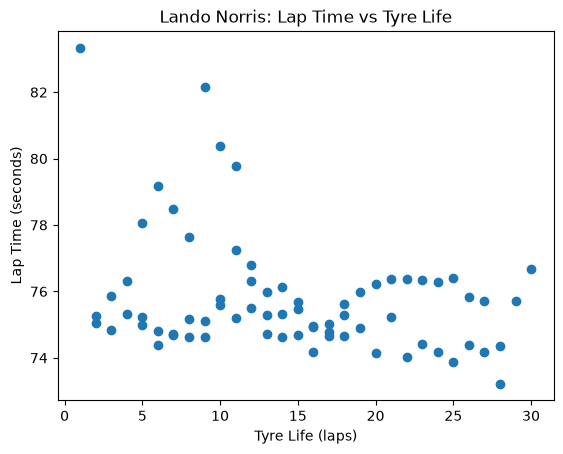

In [ ]:
plt.scatter(
    clean_norris["TyreLife"],
    clean_norris["LapTimeSeconds"]
)

plt.xlabel("Tyre Life (laps)")
plt.ylabel("Lap Time (seconds)")
plt.title("Lando Norris: Lap Time vs Tyre Life")

plt.show()

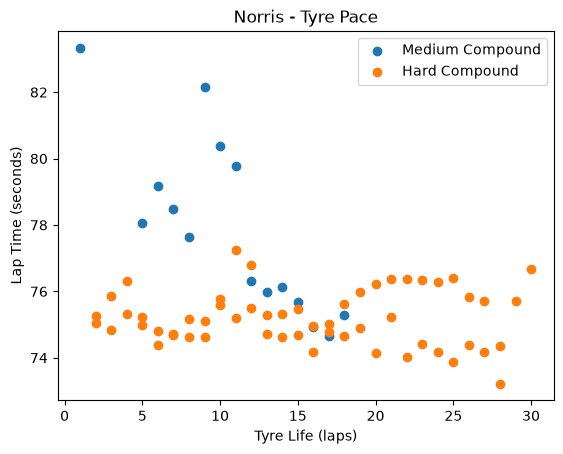

In [84]:
medium = clean_norris[clean_norris["Compound"] == "MEDIUM"]

plt.scatter(
    medium["TyreLife"],
    medium["LapTimeSeconds"],
    label = 'Medium Compound'
)
hard = clean_norris[clean_norris["Compound"] == "HARD"]

plt.scatter(
    hard["TyreLife"],
    hard["LapTimeSeconds"],
    label='Hard Compound'
)

plt.legend()
plt.xlabel("Tyre Life (laps)")
plt.ylabel("Lap Time (seconds)")
plt.title("Norris - Tyre Pace")

plt.show()

In [85]:
clean_norris.groupby("Compound")["LapTimeSeconds"].agg(
    ["mean", "std", "count"]
)

,mean,std,count
Compound,,,
HARD,75.202054,0.828285,56
MEDIUM,77.859867,2.671978,15


In [86]:
clean_norris[
    ["LapNumber", "LapTimeSeconds",
     "Sector1Time", "Sector2Time", "Sector3Time"]
].head(10)

,LapNumber,LapTimeSeconds,Sector1Time,Sector2Time,Sector3Time
734,1.0,83.340,NaT,0 days 00:00:37.264000,0 days 00:00:21.219000
738,5.0,78.050,0 days 00:00:20.559000,0 days 00:00:36.559000,0 days 00:00:20.932000
739,6.0,79.172,0 days 00:00:20.643000,0 days 00:00:37.367000,0 days 00:00:21.162000
740,7.0,78.470,0 days 00:00:20.536000,0 days 00:00:37.171000,0 days 00:00:20.763000
741,8.0,77.626,0 days 00:00:20.324000,0 days 00:00:36.551000,0 days 00:00:20.751000
742,9.0,82.148,0 days 00:00:20.524000,0 days 00:00:40.374000,0 days 00:00:21.250000
743,10.0,80.385,0 days 00:00:20.486000,0 days 00:00:38.781000,0 days 00:00:21.118000
744,11.0,79.771,0 days 00:00:20.086000,0 days 00:00:38.999000,0 days 00:00:20.686000
745,12.0,76.300,0 days 00:00:20.126000,0 days 00:00:35.936000,0 days 00:00:20.238000
746,13.0,75.988,0 days 00:00:20.017000,0 days 00:00:35.712000,0 days 00:00:20.259000


In [87]:
for sector in ["Sector1Time", "Sector2Time", "Sector3Time"]:
    clean_norris[sector + "Seconds"] = clean_norris[sector].dt.total_seconds()

In [89]:
clean_norris[
    ["Sector1TimeSeconds", "Sector2TimeSeconds", "Sector3TimeSeconds"]
].mean()
clean_norris[
    ["Sector1TimeSeconds", "Sector2TimeSeconds", "Sector3TimeSeconds"]
].std()

Sector1TimeSeconds    0.309859
Sector2TimeSeconds    0.976014
Sector3TimeSeconds    0.407916
dtype: float64

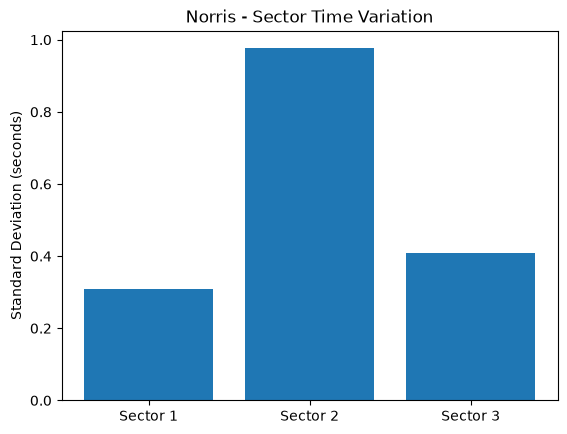

In [90]:
sector_std = clean_norris[
    ["Sector1TimeSeconds", "Sector2TimeSeconds", "Sector3TimeSeconds"]
].std()

plt.bar(
    ["Sector 1", "Sector 2", "Sector 3"],
    sector_std
)

plt.ylabel("Standard Deviation (seconds)")
plt.title("Norris - Sector Time Variation")

plt.show()

In [91]:
fastest = clean_norris.loc[clean_norris["LapTimeSeconds"].idxmin()]
slowest = clean_norris.loc[clean_norris["LapTimeSeconds"].idxmax()]

print("Fastest lap:")
print(fastest[[
    "LapNumber", "LapTimeSeconds",
    "Sector1TimeSeconds", "Sector2TimeSeconds", "Sector3TimeSeconds"
]])

print("\nSlowest lap:")
print(slowest[[
    "LapNumber", "LapTimeSeconds",
    "Sector1TimeSeconds", "Sector2TimeSeconds", "Sector3TimeSeconds"
]])

Fastest lap:
LapNumber               78.0
LapTimeSeconds        73.221
Sector1TimeSeconds    19.145
Sector2TimeSeconds    34.697
Sector3TimeSeconds    19.379
dtype: object

Slowest lap:
LapNumber                1.0
LapTimeSeconds         83.34
Sector1TimeSeconds       NaN
Sector2TimeSeconds    37.264
Sector3TimeSeconds    21.219
dtype: object


In [92]:
pace_norris = clean_norris[
    clean_norris["LapNumber"] != 1
].copy()

In [93]:
fastest = pace_norris.loc[
    pace_norris["LapTimeSeconds"].idxmin()
]

slowest = pace_norris.loc[
    pace_norris["LapTimeSeconds"].idxmax()
]

print("Fastest lap:")
print(fastest[[
    "LapNumber", "LapTimeSeconds",
    "Sector1TimeSeconds",
    "Sector2TimeSeconds",
    "Sector3TimeSeconds"
]])

print("\nSlowest lap:")
print(slowest[[
    "LapNumber", "LapTimeSeconds",
    "Sector1TimeSeconds",
    "Sector2TimeSeconds",
    "Sector3TimeSeconds"
]])

Fastest lap:
LapNumber               78.0
LapTimeSeconds        73.221
Sector1TimeSeconds    19.145
Sector2TimeSeconds    34.697
Sector3TimeSeconds    19.379
dtype: object

Slowest lap:
LapNumber                9.0
LapTimeSeconds        82.148
Sector1TimeSeconds    20.524
Sector2TimeSeconds    40.374
Sector3TimeSeconds     21.25
dtype: object


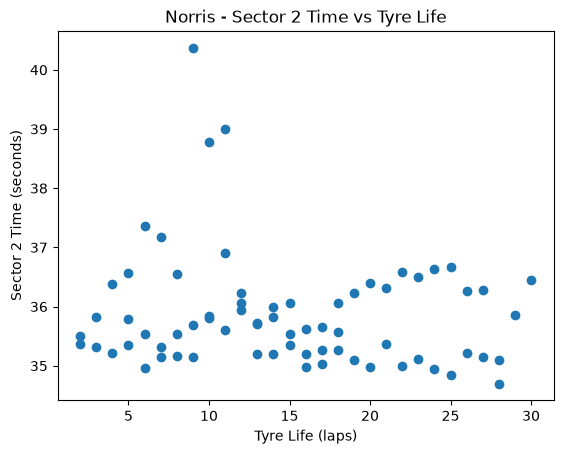

In [94]:
plt.scatter(
    pace_norris["TyreLife"],
    pace_norris["Sector2TimeSeconds"]
)

plt.xlabel("Tyre Life (laps)")
plt.ylabel("Sector 2 Time (seconds)")
plt.title("Norris - Sector 2 Time vs Tyre Life")

plt.show()

In [96]:
pace_norris[
    pace_norris["Sector2TimeSeconds"] >= 38
][[
    "LapNumber",
    "Sector2TimeSeconds",
    "TyreLife",
    "Compound",
    "TrackStatus"
]]

,LapNumber,Sector2TimeSeconds,TyreLife,Compound,TrackStatus
742,9.0,40.374,9.0,MEDIUM,2
743,10.0,38.781,10.0,MEDIUM,2
744,11.0,38.999,11.0,MEDIUM,21


In [97]:
pace_norris[
    pace_norris["Sector2TimeSeconds"] > 38
][[
    "LapNumber",
    "Sector2TimeSeconds",
    "TyreLife",
    "Compound",
    "TrackStatus",
    "LapTimeSeconds"
]]

,LapNumber,Sector2TimeSeconds,TyreLife,Compound,TrackStatus,LapTimeSeconds
742,9.0,40.374,9.0,MEDIUM,2,82.148
743,10.0,38.781,10.0,MEDIUM,2,80.385
744,11.0,38.999,11.0,MEDIUM,21,79.771


In [100]:
pace_norris[
    pace_norris["LapNumber"].isin([9, 10, 11])
][[
    "LapNumber",
    "Sector2TimeSeconds",
    "TyreLife",
    "Compound",
    "TrackStatus"
]]

,LapNumber,Sector2TimeSeconds,TyreLife,Compound,TrackStatus
742,9.0,40.374,9.0,MEDIUM,2
743,10.0,38.781,10.0,MEDIUM,2
744,11.0,38.999,11.0,MEDIUM,21


In [101]:
pace_norris["TrackStatus"].value_counts().sort_index()

TrackStatus
1     65
12     2
2      2
21     1
Name: count, dtype: int64

In [102]:
pace_norris.groupby("TrackStatus")["LapTimeSeconds"].agg(
    ["mean", "std", "count"]
)

,mean,std,count
TrackStatus,,,
1,75.400554,1.067348,65
12,76.266500,1.922623,2
2,81.266500,1.246629,2
21,79.771000,NaN,1


In [103]:
pace_norris[
    ["LapNumber", "SpeedST", "LapTimeSeconds", "Compound", "TyreLife"]
].head(10)

,LapNumber,SpeedST,LapTimeSeconds,Compound,TyreLife
738,5.0,272.0,78.050,MEDIUM,5.0
739,6.0,266.0,79.172,MEDIUM,6.0
740,7.0,273.0,78.470,MEDIUM,7.0
741,8.0,272.0,77.626,MEDIUM,8.0
742,9.0,263.0,82.148,MEDIUM,9.0
743,10.0,271.0,80.385,MEDIUM,10.0
744,11.0,207.0,79.771,MEDIUM,11.0
745,12.0,272.0,76.300,MEDIUM,12.0
746,13.0,272.0,75.988,MEDIUM,13.0
747,14.0,273.0,76.122,MEDIUM,14.0


In [104]:
pace_norris["SpeedST"].describe()

count     70.000000
mean     276.685714
std        9.426363
min      207.000000
25%      275.250000
50%      278.000000
75%      281.000000
max      286.000000
Name: SpeedST, dtype: float64

In [105]:
pace_norris[
    pace_norris["SpeedST"] < 260
][[
    "LapNumber",
    "SpeedST",
    "LapTimeSeconds",
    "Compound",
    "TyreLife",
    "TrackStatus"
]]

,LapNumber,SpeedST,LapTimeSeconds,Compound,TyreLife,TrackStatus
744,11.0,207.0,79.771,MEDIUM,11.0,21


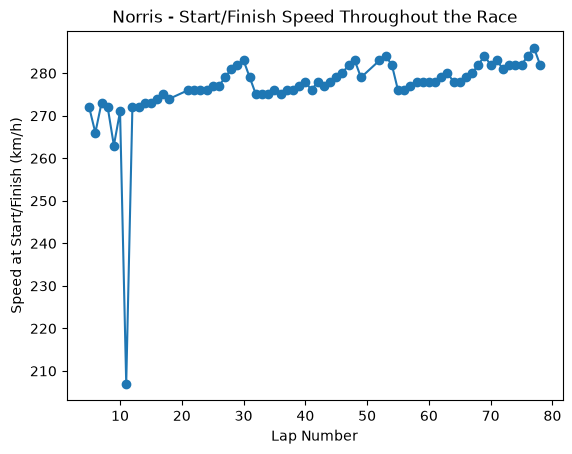

In [106]:
plt.plot(
    pace_norris["LapNumber"],
    pace_norris["SpeedST"],
    marker="o"
)

plt.xlabel("Lap Number")
plt.ylabel("Speed at Start/Finish (km/h)")
plt.title("Norris - Start/Finish Speed Throughout the Race")

plt.show()

In [107]:
pace_norris.groupby("TrackStatus")["SpeedST"].agg(
    ["mean", "std", "count"]
)

,mean,std,count
TrackStatus,,,
1,278.138462,3.741143,65
12,274.000000,2.828427,2
2,267.000000,5.656854,2
21,207.000000,NaN,1


In [108]:
pace_norris[
    ["SpeedI1", "SpeedI2", "SpeedFL", "SpeedST"]
].describe()

,SpeedI1,SpeedI2,SpeedFL,SpeedST
count,70.000000,70.000000,70.000000,70.000000
mean,203.042857,195.771429,259.457143,276.685714
std,4.147413,5.411130,3.246785,9.426363
min,193.000000,180.000000,254.000000,207.000000
25%,200.000000,193.000000,258.000000,275.250000
50%,203.500000,197.500000,259.000000,278.000000
75%,206.000000,200.000000,261.000000,281.000000
max,213.000000,204.000000,270.000000,286.000000


In [109]:
pace_norris[
    [
        "Sector1TimeSeconds",
        "Sector2TimeSeconds",
        "Sector3TimeSeconds",
        "SpeedI1",
        "SpeedI2",
        "SpeedFL",
        "SpeedST"
    ]
].corr()

,Sector1TimeSeconds,Sector2TimeSeconds,Sector3TimeSeconds,SpeedI1,SpeedI2,SpeedFL,SpeedST
Sector1TimeSeconds,1.000000,0.685025,0.779410,-0.564641,-0.762630,-0.377294,-0.369092
Sector2TimeSeconds,0.685025,1.000000,0.777598,-0.548199,-0.723062,-0.076946,-0.470788
Sector3TimeSeconds,0.779410,0.777598,1.000000,-0.580997,-0.803671,-0.186937,-0.380799
SpeedI1,-0.564641,-0.548199,-0.580997,1.000000,0.503507,-0.081120,0.160865
SpeedI2,-0.762630,-0.723062,-0.803671,0.503507,1.000000,0.149569,0.301171
SpeedFL,-0.377294,-0.076946,-0.186937,-0.081120,0.149569,1.000000,0.486349
SpeedST,-0.369092,-0.470788,-0.380799,0.160865,0.301171,0.486349,1.000000


In [111]:
laps["Compound"].value_counts()

Compound
HARD      849
MEDIUM    519
SOFT       57
Name: count, dtype: int64

In [115]:
laps["LapTimeSeconds"] = laps["LapTime"].dt.total_seconds()

In [116]:
laps.groupby("Compound")["LapTimeSeconds"].agg(
    ["mean", "std", "count"]
)

,mean,std,count
Compound,,,
HARD,79.040877,6.318768,848
MEDIUM,79.861844,8.261238,518
SOFT,79.276561,5.737843,57


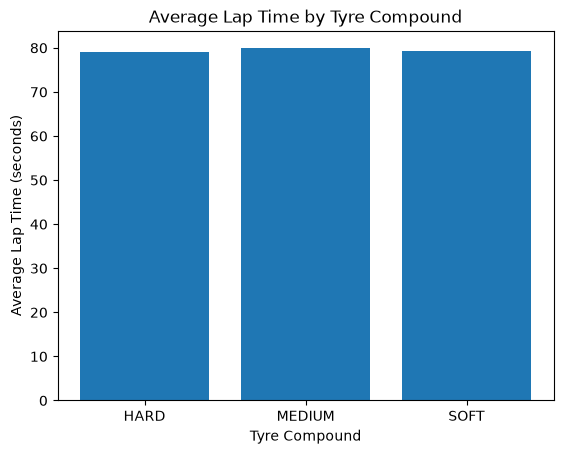

In [117]:
compound_mean = laps.groupby("Compound")["LapTimeSeconds"].mean()

plt.bar(compound_mean.index, compound_mean.values)

plt.xlabel("Tyre Compound")
plt.ylabel("Average Lap Time (seconds)")
plt.title("Average Lap Time by Tyre Compound")

plt.show()

In [118]:
laps.groupby(["Compound", "TyreLife"])["LapTimeSeconds"].count()

Compound  TyreLife
HARD      1.0         19
          2.0         26
          3.0         26
          4.0         26
          5.0         25
                      ..
SOFT      28.0         1
          29.0         1
          30.0         1
          31.0         1
          32.0         1
Name: LapTimeSeconds, Length: 163, dtype: int64

In [119]:
laps["TyreAgeGroup"] = pd.cut(
    laps["TyreLife"],
    bins=[0, 5, 15, 25, float("inf")],
    labels=["Fresh", "Low", "Medium", "High"]
)

In [120]:
laps.groupby(
    ["Compound", "TyreAgeGroup"],
    observed=True
)["LapTimeSeconds"].agg(["mean", "std", "count"])

mean        std  count
Compound TyreAgeGroup                             
HARD     Fresh         85.330361  13.129457    122
         Low           77.842581   2.641963    241
         Medium        77.485769   3.532910    195
         High          78.436459   3.282294    290
MEDIUM   Fresh         87.786356  15.200134     87
         Low           78.792314   5.407366    188
         Medium        78.213430   4.416892    114
         High          77.532837   2.869783    129
SOFT     Fresh         79.486563   8.436595     16
         Low           80.094167   5.497114     24
         Medium        78.510800   1.500631     10
         High          77.087286   0.874302      7

In [121]:
laps[
    laps["PitInTime"].notna() | laps["PitOutTime"].notna()
][[
    "LapNumber",
    "Compound",
    "TyreLife",
    "LapTimeSeconds",
    "PitInTime",
    "PitOutTime"
]].head(20)

,LapNumber,Compound,TyreLife,LapTimeSeconds,PitInTime,PitOutTime
27,28.0,HARD,28.0,92.651,0 days 01:33:29.565000,NaT
28,29.0,MEDIUM,1.0,78.571,NaT,0 days 01:33:53.706000
76,77.0,MEDIUM,49.0,93.332,0 days 02:35:22.869000,NaT
77,78.0,SOFT,4.0,77.770,NaT,0 days 02:35:46.459000
78,1.0,MEDIUM,7.0,112.223,0 days 00:57:37.624000,NaT
79,2.0,MEDIUM,1.0,108.974,NaT,0 days 00:58:01.973000
85,8.0,MEDIUM,7.0,NaN,0 days 01:08:39.977000,NaT
154,69.0,HARD,69.0,94.121,0 days 02:28:35.673000,NaT
155,70.0,MEDIUM,1.0,79.503,NaT,0 days 02:29:00.047000
156,71.0,MEDIUM,2.0,91.512,0 days 02:31:26.292000,NaT


In [122]:
clean_laps = laps[
    laps["PitInTime"].isna() &
    laps["PitOutTime"].isna()
].copy()

In [123]:
clean_laps.groupby(
    ["Compound", "TyreAgeGroup"],
    observed=True
)["LapTimeSeconds"].agg(["mean", "std", "count"])

mean        std  count
Compound TyreAgeGroup                             
HARD     Fresh         85.518702  13.391181    104
         Low           77.767271   2.374152    240
         Medium        77.009626   1.945050    190
         High          77.873832   1.613616    279
MEDIUM   Fresh         87.287386  13.410180     70
         Low           78.234648   4.329211    179
         Medium        77.208150   2.019525    107
         High          77.157770   1.527970    126
SOFT     Fresh         76.529000   1.334124     10
         Low           78.153429   1.705877     21
         Medium        78.510800   1.500631     10
         High          77.087286   0.874302      7

In [124]:
clean_laps[
    (clean_laps["TyreAgeGroup"] == "Fresh") &
    (clean_laps["LapTimeSeconds"] > 85)
][[
    "Driver",
    "LapNumber",
    "LapTimeSeconds",
    "Compound",
    "TyreLife",
    "TrackStatus"
]].head(30)

,Driver,LapNumber,LapTimeSeconds,Compound,TyreLife,TrackStatus
0,VER,1.0,87.020,HARD,1.0,12
1,VER,2.0,106.318,HARD,2.0,16
2,VER,3.0,108.815,HARD,3.0,6
3,VER,4.0,100.290,HARD,4.0,671
80,GAS,3.0,108.723,MEDIUM,2.0,6
81,GAS,4.0,91.509,MEDIUM,3.0,671
86,ANT,1.0,94.721,HARD,1.0,126
87,ANT,2.0,111.408,HARD,2.0,6
88,ANT,3.0,108.871,HARD,3.0,6
89,ANT,4.0,96.575,HARD,4.0,671


In [125]:
clean_laps["TrackStatus"].value_counts().sort_index()

TrackStatus
1      1177
12       50
126       4
16       12
2        38
21       19
6        24
671      20
Name: count, dtype: int64

In [128]:
track_status = {
    1: "All clear",
    2: "Yellow flag",
    6: "Safety car",
    12: "Safety car / yellow flag",
    16: "Virtual safety car",
    21: "Red flag",
    126: "Multiple conditions",
    671: "Multiple conditions"
}

for code in sorted(clean_laps["TrackStatus"].unique()):
    print(code, "->", track_status.get(code, "Unknown"))

1 -> Unknown
12 -> Unknown
126 -> Unknown
16 -> Unknown
2 -> Unknown
21 -> Unknown
6 -> Unknown
671 -> Unknown


In [127]:
clean_laps["TrackStatus"].value_counts().sort_index()

TrackStatus
1      1177
12       50
126       4
16       12
2        38
21       19
6        24
671      20
Name: count, dtype: int64

In [129]:
for status in sorted(clean_laps["TrackStatus"].unique()):
    print(status, bin(int(status)))

1 0b1
12 0b1100
126 0b1111110
16 0b10000
2 0b10
21 0b10101
6 0b110
671 0b1010011111
